In [56]:
def compute_mean(values):
    n = len(values)
    total =0.0
    for value in values:
        total += value
    mean = total / n
    return mean

In [36]:
def compute_variance(values, mean):
    n = len(values)
    sum_squared_diff = 0.0
    for value in values:
        sum_squared_diff += (value - mean) ** 2
    variance = sum_squared_diff / n
    return variance
    

In [69]:
def compute_accuracy(y_true, y_pred):
    correct = 0
    for true, pred in zip(y_true, y_pred):
        if true == pred:
            correct += 1
    accuracy = correct / len(y_true)
    return accuracy


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split


In [22]:
df = pd.read_csv("abalone.csv")
df.head(8)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


<Axes: >

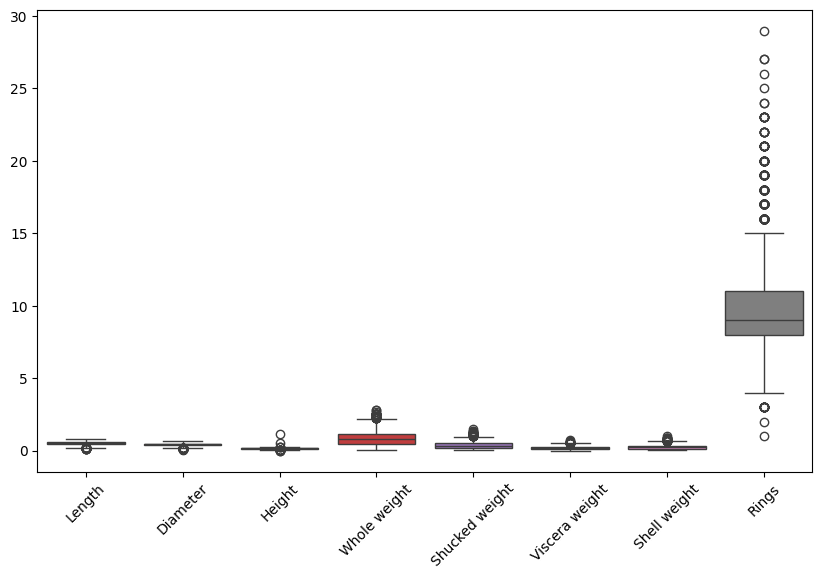

In [24]:
plt.figure(figsize=(10, 6))
plt.xticks(rotation=45)
sns.boxplot(df)


###  Convert Rings to age class

In [25]:
df['AgeClass'] = pd.cut(
    df['Rings'], 
    bins=[-1, 8, 11, float('inf')], 
    labels=['Young', 'Adult', 'Old']
    )

In [26]:
df['Sex_M'] = (df['Sex'] == 'M').astype(int)
df['Sex_F'] = (df['Sex'] == 'F').astype(int)
df['Sex_I'] = (df['Sex'] == 'I').astype(int)
df.drop(columns=['Sex', 'Rings'], inplace=True)


In [28]:
df

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,AgeClass,Sex_M,Sex_F,Sex_I
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,Old,1,0,0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,Young,1,0,0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,Adult,0,1,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,Adult,1,0,0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,Young,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,Adult,0,1,0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,Adult,1,0,0
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,Adult,1,0,0
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,Adult,0,1,0


###  Split dataset (80% training / 20% testing)

In [29]:
X = df.drop(['AgeClass'], axis=1)   
y = df['AgeClass']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [37]:
y_train.unique()

['Adult', 'Young', 'Old']
Categories (3, object): ['Young' < 'Adult' < 'Old']

### Compute class priors

In [40]:
class_priors ={}
total_samples = len(y_train)
for c in y_train.unique():
    class_priors[c] = len(y_train[y_train == c]) / total_samples

print("Class Priors:")
for c, prior in class_priors.items():
    print(f"Class {c}: {prior}")

Class Priors:
Class Adult: 0.4298114337024843
Class Young: 0.3376234660281353
Class Old: 0.23256510026938043


In [55]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3341 entries, 4038 to 860
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          3341 non-null   float64
 1   Diameter        3341 non-null   float64
 2   Height          3341 non-null   float64
 3   Whole weight    3341 non-null   float64
 4   Shucked weight  3341 non-null   float64
 5   Viscera weight  3341 non-null   float64
 6   Shell weight    3341 non-null   float64
 7   Sex_M           3341 non-null   int64  
 8   Sex_F           3341 non-null   int64  
 9   Sex_I           3341 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 287.1 KB


### Compute mean and variance for each feature per class

In [59]:
## we have 3 classes-> young , adult , old
# we have 8 features -> sex, Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight
means = {}
variances = {}

for c in y_train.unique():
    X_c = X_train[y_train == c]
    means[c] = {}
    variances[c] ={}
    for cols in X_c.columns:
        mean = compute_mean(X_c[cols])
        variance = compute_variance(X_c[cols], mean)
        means[c][cols] = mean
        variances[c][cols] = variance
    

In [60]:
means

{'Adult': {'Length': 0.5716225626740965,
  'Diameter': 0.4464623955431762,
  'Height': 0.15184888579387196,
  'Whole weight': 0.9875146239554333,
  'Shucked weight': 0.44151288300835667,
  'Viscera weight': 0.21790912256267428,
  'Shell weight': 0.27591713091922004,
  'Sex_M': 0.4387186629526462,
  'Sex_F': 0.3753481894150418,
  'Sex_I': 0.18593314763231197},
 'Young': {'Length': 0.4229521276595746,
  'Diameter': 0.3226728723404252,
  'Height': 0.10705230496453884,
  'Whole weight': 0.4355828900709223,
  'Shucked weight': 0.19921808510638297,
  'Viscera weight': 0.0938745567375887,
  'Shell weight': 0.1222668439716312,
  'Sex_M': 0.21897163120567376,
  'Sex_F': 0.1356382978723404,
  'Sex_I': 0.6453900709219859},
 'Old': {'Length': 0.5868275418275416,
  'Diameter': 0.4630180180180172,
  'Height': 0.1650321750321752,
  'Whole weight': 1.1150868725868721,
  'Shucked weight': 0.4451769626769629,
  'Viscera weight': 0.23854890604890616,
  'Shell weight': 0.34316859716859666,
  'Sex_M': 0.44

In [61]:
variances

{'Adult': {'Length': 0.007638732192875612,
  'Diameter': 0.005121886468913177,
  'Height': 0.0009082285572543667,
  'Whole weight': 0.18440746879728198,
  'Shucked weight': 0.04412039172121466,
  'Viscera weight': 0.009634389199508646,
  'Shell weight': 0.012130090973941077,
  'Sex_M': 0.24624459772968976,
  'Sex_F': 0.2344619261178926,
  'Sex_I': 0.15136201224385445},
 'Young': {'Length': 0.01196681685717524,
  'Diameter': 0.007967478980402124,
  'Height': 0.0019077339663183435,
  'Whole weight': 0.09321330496434256,
  'Shucked weight': 0.02151237885732607,
  'Viscera weight': 0.004610558067179407,
  'Shell weight': 0.006561089698550118,
  'Sex_M': 0.17102305593279787,
  'Sex_F': 0.11724055002263362,
  'Sex_I': 0.22886172727730408},
 'Old': {'Length': 0.006564999859208357,
  'Diameter': 0.0045021850035363445,
  'Height': 0.0008594905992589431,
  'Whole weight': 0.20967557449948568,
  'Shucked weight': 0.04396529526078756,
  'Viscera weight': 0.010139684223385003,
  'Shell weight': 0.0

### Implement Gaussian probability density function

In [65]:
def gaussian_pdf(x, mean, var):
    eps = 1e-9  
    coeff = 1 / np.sqrt(2 * np.pi * (var + eps))
    exponent = np.exp(- ((x - mean) ** 2) / (2 * (var + eps)))
    return coeff * exponent

###  Predict test samples

In [67]:
y_predicted = []

for i in range(len(X_test)):
    x = X_test.iloc[i]
    best_class = None
    
    probabilities = {}
    
    for c in y_train.unique():
        prior = class_priors[c]
        likelihood = 1.0
        for featuer in X_test.columns:
            mean = means[c][featuer]
            var = variances[c][featuer]
            likelihood *= gaussian_pdf(x[featuer], mean, var)
        posterior = prior * likelihood
        probabilities[c] = posterior
        
    for c, prob in probabilities.items():
        if best_class is None or prob > probabilities[best_class]:
            best_class = c
    y_predicted.append(best_class)
    
    
    
    

        
    
    

###  Compute accuracy using your custom function

In [70]:
accuracy = compute_accuracy(y_test, y_predicted)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5526


### Create a predict function that takes a single test sample

In [71]:
def predict_single_test(x):
    best_class = None
    probabilities = {}
    
    for c in y_train.unique():
        prior = class_priors[c]
        likelihood = 1.0
        for featuer in X_test.columns:
            mean = means[c][featuer]
            var = variances[c][featuer]
            likelihood *= gaussian_pdf(x[featuer], mean, var)
        posterior = prior * likelihood
        probabilities[c] = posterior
        
    for c, prob in probabilities.items():
        if best_class is None or prob > probabilities[best_class]:
            best_class = c
    return best_class

In [72]:
test_instance = X_test.iloc[2]
predicted_class = predict_single_test(test_instance)
print(f"Predicted class for the test instance: {predicted_class}")

Predicted class for the test instance: Old


In [73]:
actual_test_instance = y_test.iloc[2]
print(f"Actual class for the test instance: {actual_test_instance}")


Actual class for the test instance: Old


### create predict_prob function that takes a single test sample

In [75]:
def predict_probabilities(x):
    probabilities = {}
    
    for c in y_train.unique():
        prior = class_priors[c]
        likelihood = 1.0
        for featuer in X_test.columns:
            mean = means[c][featuer]
            var = variances[c][featuer]
            likelihood *= gaussian_pdf(x[featuer], mean, var)
        posterior = prior * likelihood
        probabilities[c] = posterior
        
    return probabilities



In [76]:
test_instance = X_test.iloc[2]
probabilities = predict_probabilities(test_instance)
print("Predicted probabilities for each class:")
for c, prob in probabilities.items():
    print(f"Class {c}: {prob:.6f}")

Predicted probabilities for each class:
Class Adult: 166.807329
Class Young: 0.001285
Class Old: 211.937942
